# Exploratory Data Analysis

## Loading the data:

In [1]:
import tarfile
import os
import json
import pandas as pd

In [2]:
tar_path = "/Users/kiradamo/Documents/CSC 577/Final Project/Yelp JSON/yelp_dataset.tar"
extract_path = "/Users/kiradamo/Documents/CSC 577/Final Project/Yelp JSON"
os.makedirs(extract_path, exist_ok=True)

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path, members=tar.getmembers())  # keeps it safe

/var/folders/c8/2bjwc5q11jj3f4jtqxxls6gc0000gn/T/ipykernel_80668/2636790333.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path, members=tar.getmembers())  # keeps it safe


The Tar file consists of 1 PDF and 5 JSON files. 

The JSON files and their attributes are:
* **Business**:
    *  business_id, name, address, city, state, postal code, latitude, longitude, stars, review_count, is_open, attributes, RestaurantsTakeOut, BusinessParking, categories, hours
* **Review**:
    * review_id, user_id, business_id, stars, date, text, useful, funny, cool
* **User**:
    * user_id, name, review_count, yelping_since, friends, useful, funny, cool, fans, elite, average_stars, compliment_hot, compliment_more, compliment_profile, compliment_cute, compliment_list, compliment_note, compliment_plain, compliment_cool, compliment_ffunny, compliment_writer, compliment_photos
* **Checkin**
    * business_id, date
* **Tip**
    * text, date, compliment_count, business_id, user_id
* **Photo**
    * photo_id, business_id, caption, label 


In [3]:
business_file = 'yelp_academic_dataset_business.json'
checkin_file = 'yelp_academic_dataset_checkin.json'
review_file =  'yelp_academic_dataset_review.json'
tip_file =  'yelp_academic_dataset_tip.json'
user_file =  'yelp_academic_dataset_user.json'

In [4]:
business_data = []
with open(f'{extract_path}/{business_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        business_data.append(json.loads(line))

business_df = pd.DataFrame(business_data)
business_df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [5]:
review_data = []
with open(f'{extract_path}/{review_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        review_data.append(json.loads(line))

review_df = pd.DataFrame(review_data)
review_df.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [6]:
checkin_data = []
with open(f'{extract_path}/{checkin_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        checkin_data.append(json.loads(line))

checkin_df = pd.DataFrame(checkin_data)
checkin_df.head()

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


In [7]:
tip_data = []
with open(f'{extract_path}/{tip_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        tip_data.append(json.loads(line))

tip_df = pd.DataFrame(tip_data)
tip_df.head()

,user_id,business_id,text,date,compliment_count
0,AGNUgVwnZUey3gcPCJ76iw,3uLgwr0qeCNMjKenHJwPGQ,Avengers time with the ladies.,2012-05-18 02:17:21,0
1,NBN4MgHP9D3cw--SnauTkA,QoezRbYQncpRqyrLH6Iqjg,They have lots of good deserts and tasty cuban...,2013-02-05 18:35:10,0
2,-copOvldyKh1qr-vzkDEvw,MYoRNLb5chwjQe3c_k37Gg,It's open even when you think it isn't,2013-08-18 00:56:08,0
3,FjMQVZjSqY8syIO-53KFKw,hV-bABTK-glh5wj31ps_Jw,Very decent fried chicken,2017-06-27 23:05:38,0
4,ld0AperBXk1h6UbqmM80zw,_uN0OudeJ3Zl_tf6nxg5ww,Appetizers.. platter special for lunch,2012-10-06 19:43:09,0


In [8]:
user_data = []
with open(f'{extract_path}/{user_file}', 'r') as f:
    for i, line in enumerate(f):
        if i > 10000:  # limit to first 10k rows for quick EDA
            break
        user_data.append(json.loads(line))

user_df = pd.DataFrame(user_data)
user_df.head()

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


## User Data

In [9]:
user_df.describe()

,review_count,useful,funny,cool,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
count,10001.000000,10001.000000,10001.000000,10001.00000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000
mean,278.590641,911.575442,465.394061,606.29967,32.556544,3.832163,60.310969,8.323368,6.861914,5.404460,3.414959,38.886911,95.097690,85.797320,85.797320,33.113989,23.823818
std,502.613179,3695.182871,2292.865663,3071.13992,162.938223,0.447322,337.469773,64.611146,97.449155,38.825055,39.375894,186.291158,606.296052,451.360398,451.360398,184.164556,245.558290
min,1.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.000000,45.000000,10.000000,14.00000,2.000000,3.590000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
50%,115.000000,176.000000,55.000000,68.00000,7.000000,3.840000,3.000000,2.000000,0.000000,0.000000,0.000000,5.000000,6.000000,6.000000,6.000000,3.000000,1.000000
75%,323.000000,628.000000,239.000000,299.00000,25.000000,4.080000,20.000000,5.000000,2.000000,2.000000,1.000000,19.000000,28.000000,33.000000,33.000000,16.000000,4.000000
max,16567.000000,173089.000000,98459.000000,144849.00000,12497.000000,5.000000,12391.000000,4347.000000,7039.000000,1744.000000,2607.000000,8616.000000,28974.000000,13280.000000,13280.000000,7309.000000,14045.000000


In [10]:
from matplotlib import pyplot as plt
import numpy as np

Text(0.5, 1.0, 'Distribution of Review Counts (User Data)')

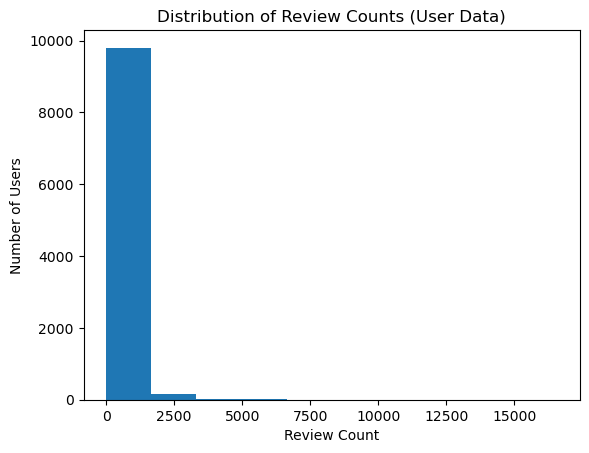

In [43]:
plt.hist(user_df['review_count'])
plt.xlabel('Review Count')
plt.ylabel('Number of Users')
plt.title('Distribution of Review Counts (User Data)')

Distribution of review count is extremely right skewed because users normally right 0-10 reviews and then there are "super-users" who will write many reviews. To handle the vast difference of these numbers and to get a more clear idea of the distribution, the review counts will need to be log-transformed.

Text(0.5, 1.0, 'Distribution of Review Counts (User Data)')

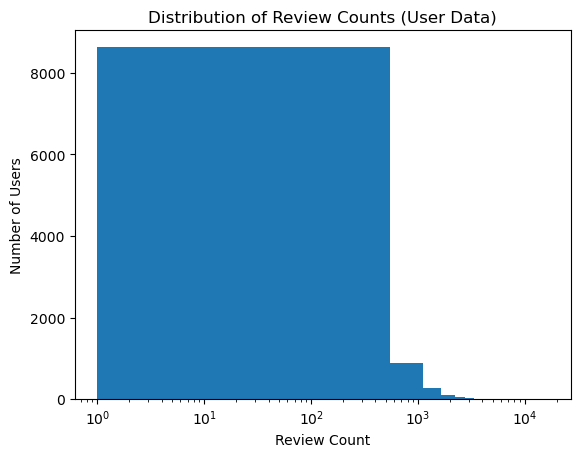

In [44]:
plt.hist(user_df['review_count'], bins=30)
plt.xscale('log')
plt.xlabel('Review Count')
plt.ylabel('Number of Users')
plt.title('Distribution of Review Counts (User Data)')

Since review count is highly skewed since most users contribute a small amount of reviews, this may foreshadow obstacles with sparsity for collaborative filtering models as well as the "cold-start" problem that most recommender systems face.

Text(0.5, 1.0, 'Distribution of Average Stars')

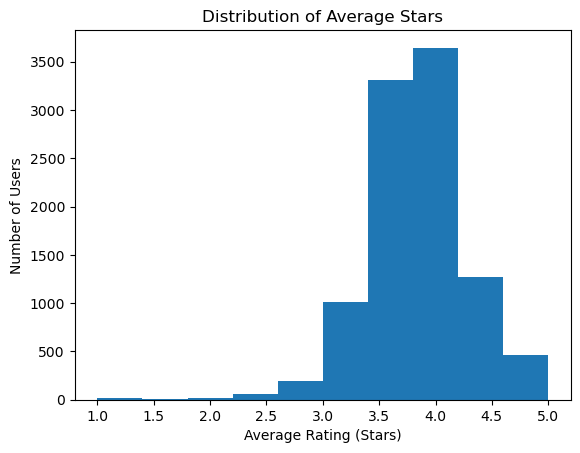

In [42]:
plt.hist(user_df['average_stars'])
plt.xlabel('Average Rating (Stars)')
plt.ylabel('Number of Users')
plt.title('Distribution of Average Stars')

The average stars is left skewed. Users may be more inclined to share positive experiences they had with a restaurant. A higher positive bias will reduce variance. This may cause difficulties for restaurants to outrank another due to little distinction of good to great businesses. Consequently, the RMSE may be lowered if the training consistently uses higher ratings.

In [14]:
user_df['average_stars'].std()

0.44732200024010726

Since the stars are mostly in the range of 3.5 - 4.5 and the variance is low, this makes personalized recommendation more difficult to implement.

### Elite Members

The dataset includes if users are considered elite. Elite users are verified by Yelp as great contributers to the community and leave many reviews. These have a more stable account of reviews.

In [15]:
user_df.columns

Index(['user_id', 'name', 'review_count', 'yelping_since', 'useful', 'funny',
       'cool', 'elite', 'friends', 'fans', 'average_stars', 'compliment_hot',
       'compliment_more', 'compliment_profile', 'compliment_cute',
       'compliment_list', 'compliment_note', 'compliment_plain',
       'compliment_cool', 'compliment_funny', 'compliment_writer',
       'compliment_photos'],
      dtype='object')

In [16]:
user_df['is_elite'] = user_df['elite'].apply(lambda x: 1 if x else 0)
user_df['is_elite']

0        1
1        1
2        1
3        1
4        0
        ..
9996     0
9997     1
9998     1
9999     0
10000    0
Name: is_elite, Length: 10001, dtype: int64

In [17]:
user_df.groupby('is_elite')['average_stars'].mean()

is_elite
0    3.857316
1    3.806321
Name: average_stars, dtype: float64

In [18]:
user_df.groupby('is_elite')['review_count'].mean()

is_elite
0     78.017758
1    484.652544
Name: review_count, dtype: float64

The elite members have a much higher review count than non-elite members.

### Engagement Features 

Engagement features such as fans, useful, funny, and cool can be helpful for hybrid recommenders or defining weighted influence.

In [19]:
user_df[['fans', 'useful', 'funny', 'cool']].describe()

,fans,useful,funny,cool
count,10001.000000,10001.000000,10001.000000,10001.00000
mean,32.556544,911.575442,465.394061,606.29967
std,162.938223,3695.182871,2292.865663,3071.13992
min,0.000000,0.000000,0.000000,0.00000
25%,2.000000,45.000000,10.000000,14.00000
50%,7.000000,176.000000,55.000000,68.00000
75%,25.000000,628.000000,239.000000,299.00000
max,12497.000000,173089.000000,98459.000000,144849.00000


Features like this are typically extremely skewed.

<Axes: >

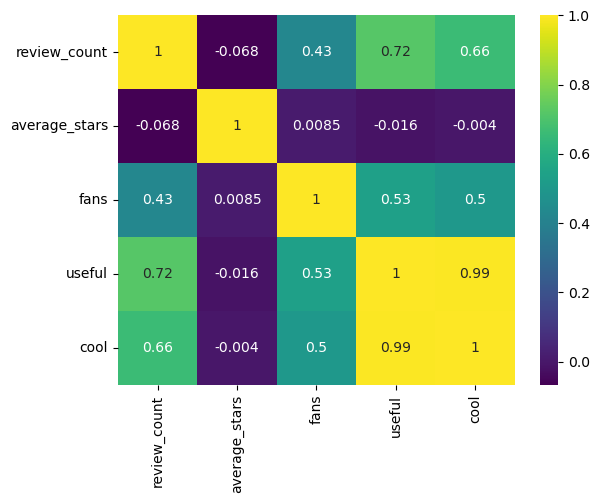

In [20]:
import seaborn as sns
corr = user_df[['review_count','average_stars','fans','useful','cool']].corr()
sns.heatmap(corr, annot=True, cmap='viridis')

If a user has more reviews, they will likely have more engagement. These engagement features may be redundant. Since the models that will be used are non-personalied and personalized content-based recommenders, engagement will not be a necessary variable to observe.

Furthermore, compliment features will also be discarded as part of variable pruning because they are not relevant to business recommendations. Since the content-based recommender is based on textual similarity rather than engagement similarity, these features will not be used to reduce noice in the data.

In [21]:
user_df.columns

Index(['user_id', 'name', 'review_count', 'yelping_since', 'useful', 'funny',
       'cool', 'elite', 'friends', 'fans', 'average_stars', 'compliment_hot',
       'compliment_more', 'compliment_profile', 'compliment_cute',
       'compliment_list', 'compliment_note', 'compliment_plain',
       'compliment_cool', 'compliment_funny', 'compliment_writer',
       'compliment_photos', 'is_elite'],
      dtype='object')

The final variables from the user data that will be implemented into the recommender systems are user ID, review counts, and average stars. The user ID's will be used for linking with similarity. 

## Business Data

In [22]:
business_df

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,N-4ZOrM_qAnzBiCsJ7-ENA,Ricky's All Day Grill,140 Street Albert Road,St Albert,AB,T8N 7C8,53.620257,-113.611680,3.0,16,1,"{'RestaurantsAttire': 'u'casual'', 'BikeParkin...","Canadian (New), American (New), Restaurants",None
9997,KqvaJX11rb4Hp70D8Dw4oQ,Admirals Club PHL Terminal F,8000 Essington Ave,Philadelphia,PA,19153,39.880694,-75.237370,4.0,10,1,"{'Alcohol': ''full_bar'', 'HappyHour': 'False'...","Bars, Nightlife, Airport Lounges","{'Monday': '5:0-21:30', 'Tuesday': '5:0-21:30'..."
9998,Yv6HUVu7fRMnt_NtGdVQBw,Las Palmas Mexican Restaurant,1905 Hayes St,Nashville,TN,37203,36.152919,-86.798455,3.5,158,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Restaurants, Mexican","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:30',..."
9999,rwsVxJqln-0HZFg1zxWtwQ,Adams Printing & Graphics,430 E Gutierrez St,Santa Barbara,CA,93101,34.420475,-119.688710,4.5,7,1,{'BusinessAcceptsCreditCards': 'True'},"Professional Services, Local Services, Printin...","{'Monday': '8:0-17:0', 'Tuesday': '8:0-17:0', ..."


Since Yelp caters to all businesses, the target attribute is Restuarants. To only observe the restaurant data, any businesses with the category "business" will be gathered.

In [23]:
businesses = business_df[business_df['categories'].str.contains("Restaurants", na=False)]

The restaurants that will also be recommended need to still remain open. So the restuarants that return as 1 or True for is_open will be selected as well.

In [24]:
businesses = business_df[business_df['is_open'] == 1]
businesses

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
6,n_0UpQx1hsNbnPUSlodU8w,Famous Footwear,"8522 Eager Road, Dierbergs Brentwood Point",Brentwood,MO,63144,38.627695,-90.340465,2.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Sporting Goods, Fashion, Shoe Stores, Shopping...","{'Monday': '0:0-0:0', 'Tuesday': '10:0-18:0', ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,N-4ZOrM_qAnzBiCsJ7-ENA,Ricky's All Day Grill,140 Street Albert Road,St Albert,AB,T8N 7C8,53.620257,-113.611680,3.0,16,1,"{'RestaurantsAttire': 'u'casual'', 'BikeParkin...","Canadian (New), American (New), Restaurants",None
9997,KqvaJX11rb4Hp70D8Dw4oQ,Admirals Club PHL Terminal F,8000 Essington Ave,Philadelphia,PA,19153,39.880694,-75.237370,4.0,10,1,"{'Alcohol': ''full_bar'', 'HappyHour': 'False'...","Bars, Nightlife, Airport Lounges","{'Monday': '5:0-21:30', 'Tuesday': '5:0-21:30'..."
9998,Yv6HUVu7fRMnt_NtGdVQBw,Las Palmas Mexican Restaurant,1905 Hayes St,Nashville,TN,37203,36.152919,-86.798455,3.5,158,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Restaurants, Mexican","{'Monday': '0:0-0:0', 'Tuesday': '11:0-21:30',..."
9999,rwsVxJqln-0HZFg1zxWtwQ,Adams Printing & Graphics,430 E Gutierrez St,Santa Barbara,CA,93101,34.420475,-119.688710,4.5,7,1,{'BusinessAcceptsCreditCards': 'True'},"Professional Services, Local Services, Printin...","{'Monday': '8:0-17:0', 'Tuesday': '8:0-17:0', ..."


In [25]:
businesses.columns

Index(['business_id', 'name', 'address', 'city', 'state', 'postal_code',
       'latitude', 'longitude', 'stars', 'review_count', 'is_open',
       'attributes', 'categories', 'hours'],
      dtype='object')

Since city is NOT included in user data, all attributes pertaining to location will be discarded. Other attributes such as hours, review_count, and name will be disregarded in the modeling process. For models such as K Nearest Neighbors and Item-based filtering, the variables that are the most relevant to recommendation are business_id, categories, attributes, and stars. 

In [26]:
print('Total Restaurants: ', businesses.shape[0])

Total Restaurants:  7968


Text(0, 0.5, 'Number of Restaurants')

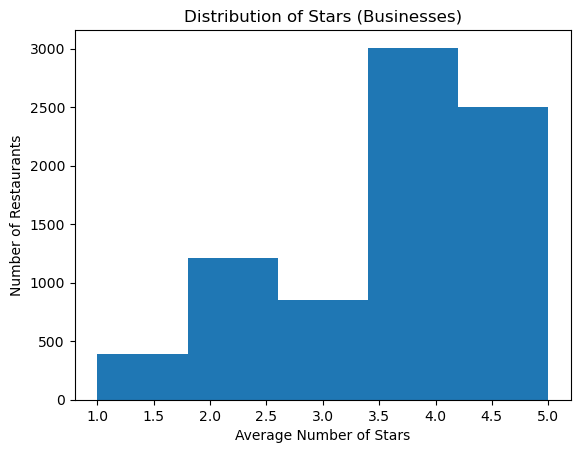

In [46]:
#Rating Distribution
plt.hist(businesses['stars'], bins = 5)
plt.title('Distribution of Stars (Businesses)')
plt.xlabel('Average Number of Stars')
plt.ylabel('Number of Restaurants')

In [28]:
all_categories = businesses['categories'].str.split(', ').explode()
print(all_categories.value_counts(ascending=False).head(20))

categories
Restaurants                  2300
Food                         1381
Shopping                     1335
Home Services                 903
Beauty & Spas                 822
Health & Medical              724
Local Services                690
Automotive                    647
Event Planning & Services     579
Nightlife                     542
Bars                          484
Active Life                   471
Sandwiches                    392
Fast Food                     354
Pizza                         346
Hotels & Travel               344
American (Traditional)        334
Auto Repair                   334
Home & Garden                 329
Coffee & Tea                  327
Name: count, dtype: int64


## Review Data

In [29]:
review_df

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
...,...,...,...,...,...,...,...,...,...
9996,UIkEO-10J6Y99IhRqUflvg,lYAmgL_l7A3MPFYe1DYKrw,EpREWeEpmR8f1qLHzzF0AA,5.0,0,1,0,Just about to get tucked into a meatloaf that ...,2018-01-09 20:26:13
9997,S-NQM3Axcg8JS3MXHUIvyw,rE2WwfgJbYfvDwBlgq__dQ,dvidzWEPgTQPeBc8CUV2OQ,5.0,0,0,0,Outstanding customer service! And my car is dr...,2015-04-01 21:50:28
9998,ME79YrEhm2xe4IQy_0zkGw,OnIklvzKDpk1BduC84TrTA,2XYPFRm7teCUr3eGsB2-qw,5.0,0,0,0,I and my husband went here for Dinner one day ...,2015-06-08 19:32:26
9999,05oKtleZ-JFGD6qt47VQcg,p0MhNWkwOPBfRo8qUb7faw,rnaE88k8yV5pFAGJeiIK4Q,2.0,0,0,0,I saw Big Data when they came to town at the K...,2015-08-06 23:16:58


Much like the user data, engagement attributes will be discarded.

In [30]:
reviews = review_df.drop(['useful', 'funny', 'cool'], axis=1)
reviews

,review_id,user_id,business_id,stars,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
...,...,...,...,...,...,...
9996,UIkEO-10J6Y99IhRqUflvg,lYAmgL_l7A3MPFYe1DYKrw,EpREWeEpmR8f1qLHzzF0AA,5.0,Just about to get tucked into a meatloaf that ...,2018-01-09 20:26:13
9997,S-NQM3Axcg8JS3MXHUIvyw,rE2WwfgJbYfvDwBlgq__dQ,dvidzWEPgTQPeBc8CUV2OQ,5.0,Outstanding customer service! And my car is dr...,2015-04-01 21:50:28
9998,ME79YrEhm2xe4IQy_0zkGw,OnIklvzKDpk1BduC84TrTA,2XYPFRm7teCUr3eGsB2-qw,5.0,I and my husband went here for Dinner one day ...,2015-06-08 19:32:26
9999,05oKtleZ-JFGD6qt47VQcg,p0MhNWkwOPBfRo8qUb7faw,rnaE88k8yV5pFAGJeiIK4Q,2.0,I saw Big Data when they came to town at the K...,2015-08-06 23:16:58


User-based distribution of reviews:

In [31]:
reviews_per_user = reviews.groupby('user_id')['business_id'].count()
print(reviews_per_user.describe())

count    9472.000000
mean        1.055849
std         0.267845
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         6.000000
Name: business_id, dtype: float64


In [32]:
avg_stars_per_user = reviews.groupby('user_id')['stars'].mean()
print(avg_stars_per_user.describe())

count    9472.000000
mean        3.854239
std         1.349384
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: stars, dtype: float64


Item-based distribution of reviews:

In [33]:
reviews_per_business = reviews.groupby('business_id')['stars'].count()
print(reviews_per_business.describe())

count    3930.000000
mean        2.544784
std         3.585008
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        85.000000
Name: stars, dtype: float64


In [34]:
avg_stars_per_business = reviews.groupby('business_id')['stars'].mean()
print(avg_stars_per_business.describe())

count    3930.000000
mean        3.761656
std         1.274854
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: stars, dtype: float64


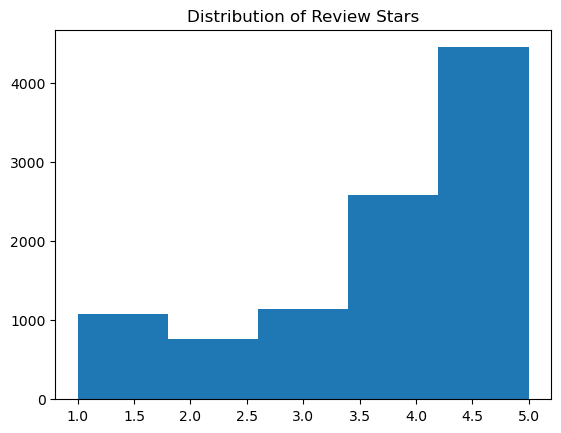

In [35]:
plt.hist(reviews['stars'], bins=5)
plt.title("Distribution of Review Stars")
plt.show()

The attributes used for reviews will be user_id, business_id, stars, and text. Text will be used for content-based recommendations. The text attribute will utilize TFxIDF for review similarity.

## Conclusion of EDA

To build a recommendation system for restaurants, the data must be concise and relevant to the user.

The Final Datasets that will be utilized for this project are:
* **Business**:
    * *Data is filtered to only be restaurants and open* 
    *  business_id, stars, review_count, attributes, categories
* **Review**:
    * review_id, user_id, business_id, stars, text
* **User**:
    * user_id,review_count, average_stars 

The other datasets, Checkin, Tip, and Photo will not be used in these models. The check-in data measures popularity over time which is not relevant to content-based K nearest neighbors or Item-based collaborative filtering. Although Tips are not entirely useless, they can add extra information but it may contribute noise to the data. The primary text from the reviews data is sufficient enough to not need tips. This data would require a longer timeline to implement into our models.